In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# NSMC 감성 분석 프로젝트 (klue/bert-base)

**Node: Huggingface Transformers 활용 - 커스텀 프로젝트**

---

## 프로젝트 개요

GLUE benchmark의 한국어 버전인 KLUE benchmark의 **모델(`klue/bert-base`)** 을 활용하여,
**NSMC(Naver Sentiment Movie Corpus)** 영화 리뷰 감성 이진 분류(긍정/부정) task를 수행합니다.

| 항목 | 내용 |
|---|---|
| 모델 | `klue/bert-base` (BERT-base, 한국어 사전학습) |
| 데이터셋 | NSMC (train 150,000 / test 50,000) |
| Task | Binary Sentiment Classification (0=부정, 1=긍정) |
| 목표 | Validation Accuracy **90% 이상** |

## 진행 순서

| STEP | 내용 |
|---|---|
| STEP 0 | 환경 설정 및 라이브러리 버전 확인 |
| STEP 1 | NSMC 데이터 분석(EDA) 및 Huggingface `DatasetDict` 구성 |
| STEP 2 | `klue/bert-base` model 및 tokenizer 불러오기 |
| STEP 3 | 토크나이저로 데이터셋 전처리 및 동작 확인 학습 |
| STEP 4 | Fine-tuning으로 모델 성능(accuracy) 90% 이상 향상 |
| STEP 5 | Bucketing(dynamic padding + `group_by_length`) 적용 및 STEP 4와 비교 |
| 결론 | 성능 / 훈련 시간 trade-off 종합 분석 |


---
# STEP 0. 환경 설정 및 라이브러리 버전 확인

## 0-1. 라이브러리 설치

> **참고**: `datasets` 라이브러리가 텐서 변환 시 `torchvision.io.VideoReader`를 import하려다
> 버전 불일치로 `ImportError`가 발생하는 경우가 있습니다.
> 본 프로젝트는 비전 모듈이 전혀 필요 없으므로 `torchvision`을 제거하여 이 경로를 원천 차단합니다.
> **아래 셀 실행 후 반드시 런타임(커널)을 재시작**하고, 그 다음 셀부터 이어서 실행해주세요.

In [2]:
# 필요한 라이브러리 설치 / 업데이트
!pip install -q -U transformers datasets accelerate evaluate scikit-learn

# torchvision - datasets 버전 충돌 회피 (본 프로젝트에서 torchvision은 불필요)
!pip uninstall -y torchvision

print()
print("=" * 60)
print(" 설치 완료. 런타임(커널)을 재시작한 뒤 다음 셀부터 실행해주세요.")
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.4 MB/s eta 0:00:00
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128

 설치 완료. 런타임(커널)을 재시작한 뒤 다음 셀부터 실행해주세요.


## 0-2. 사용할 라이브러리 버전 확인

프로젝트 가이드에서 요구한 버전 확인 단계입니다.

In [3]:
import tensorflow
import numpy
import transformers
import datasets

print("tensorflow   :", tensorflow.__version__)
print("numpy        :", numpy.__version__)
print("transformers :", transformers.__version__)
print("datasets     :", datasets.__version__)

tensorflow   : 2.20.0
numpy        : 2.0.2
transformers : 5.14.1
datasets     : 5.0.0


## 0-3. 공통 import 및 실험 환경 설정

실험의 **재현성(reproducibility)** 과 **공정한 비교**를 위해 seed를 고정합니다.
STEP 4와 STEP 5는 padding 전략만 다르고 나머지 하이퍼파라미터는 완전히 동일하게 유지하여,
성능/시간 차이가 오직 bucketing에서 비롯되도록 통제합니다.

In [4]:
import os
import gc
import time
import random
import warnings

import numpy as np
import pandas as pd
import torch

warnings.filterwarnings('ignore')

SEED = 42

def set_seed(seed=SEED):
    """재현성 확보를 위한 시드 고정"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# GPU 확인 - fp16 사용 가능 여부 판단
use_cuda = torch.cuda.is_available()
use_fp16 = use_cuda

print("CUDA available :", use_cuda)
if use_cuda:
    print("GPU            :", torch.cuda.get_device_name(0))
    print("VRAM           : %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1024**3))
print("fp16 사용      :", use_fp16)


def clear_memory(*objs):
    """모델/트레이너 삭제 후 CUDA 캐시까지 확실히 정리"""
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("메모리 정리 완료")

CUDA available : True
GPU            : Tesla T4
VRAM           : 14.6 GB
fp16 사용      : True


---
# STEP 1. NSMC 데이터 분석 및 Huggingface dataset 구성

## 1-1. 데이터 불러오기

NSMC는 두 가지 경로로 가져올 수 있습니다.

1. **Huggingface Hub** — `load_dataset('e9t/nsmc')`
2. **GitHub 원본** — `ratings_train.txt`, `ratings_test.txt` 직접 다운로드

Hub 우선으로 시도하되, 네트워크/스크립트 이슈로 실패하면 GitHub 원본으로 자동 fallback 하도록 작성했습니다.

> 앞선 실습에서 `load_dataset('glue', 'mrpc')`가 `HfUriError`로 실패했던 것처럼,
> 최신 `datasets`는 리포지토리를 반드시 `namespace/name` 형식으로 요구합니다.
> 그래서 `'nsmc'`가 아닌 **`'e9t/nsmc'`** 로 지정해야 합니다.

In [5]:
from datasets import load_dataset, Dataset, DatasetDict

raw_train_df, raw_test_df = None, None

# 방법 1: Huggingface Hub 에서 로드
try:
    nsmc = load_dataset('e9t/nsmc', trust_remote_code=True)
    print("[성공] Huggingface Hub 에서 로드했습니다.")
    print(nsmc)
    raw_train_df = nsmc['train'].to_pandas()
    raw_test_df = nsmc['test'].to_pandas()

# 방법 2: GitHub 원본 파일로 fallback
except Exception as e:
    print("[알림] Hub 로드 실패 -> GitHub 원본으로 대체합니다.")
    print("       사유:", type(e).__name__, str(e)[:200])

    TRAIN_URL = 'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt'
    TEST_URL  = 'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt'

    raw_train_df = pd.read_csv(TRAIN_URL, sep='\t')
    raw_test_df  = pd.read_csv(TEST_URL,  sep='\t')
    print("[성공] GitHub 원본에서 로드했습니다.")

print()
print("train shape :", raw_train_df.shape)
print("test  shape :", raw_test_df.shape)
print("columns     :", raw_train_df.columns.tolist())

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'e9t/nsmc' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'e9t/nsmc' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md:   0%|          | 0.00/3.74k [00:00<?, ?B/s]

nsmc.py:   0%|          | 0.00/3.18k [00:00<?, ?B/s]

[알림] Hub 로드 실패 -> GitHub 원본으로 대체합니다.
       사유: RuntimeError Dataset scripts are no longer supported, but found nsmc.py
[성공] GitHub 원본에서 로드했습니다.

train shape : (150000, 3)
test  shape : (50000, 3)
columns     : ['id', 'document', 'label']


In [6]:
# 원본 데이터 샘플 확인
raw_train_df.head(10)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1
5,5403919,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.,0
6,7797314,원작의 긴장감을 제대로 살려내지못했다.,0
7,9443947,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,0
8,7156791,액션이 없는데도 재미 있는 몇안되는 영화,1
9,5912145,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,1


## 1-2. 탐색적 데이터 분석 (EDA)

모델을 학습시키기 전에 데이터의 특성을 먼저 파악합니다.
특히 **결측치, 중복, 라벨 분포, 문장 길이 분포**는 전처리 방향과
`max_length` 같은 하이퍼파라미터 결정에 직접적인 영향을 줍니다.

In [7]:
print("=" * 60)
print(" 1) 결측치 확인")
print("=" * 60)
print("[train]")
print(raw_train_df.isnull().sum())
print()
print("[test]")
print(raw_test_df.isnull().sum())

print()
print("=" * 60)
print(" 2) 라벨 분포 확인 (클래스 균형)")
print("=" * 60)
print("[train]")
print(raw_train_df['label'].value_counts().sort_index())
print("비율:", (raw_train_df['label'].value_counts(normalize=True).sort_index().round(4)).to_dict())
print()
print("[test]")
print(raw_test_df['label'].value_counts().sort_index())
print("비율:", (raw_test_df['label'].value_counts(normalize=True).sort_index().round(4)).to_dict())

print()
print("=" * 60)
print(" 3) 중복 데이터 확인")
print("=" * 60)
print("train 중복 document 수 :", raw_train_df['document'].duplicated().sum())
print("test  중복 document 수 :", raw_test_df['document'].duplicated().sum())

 1) 결측치 확인
[train]
id          0
document    5
label       0
dtype: int64

[test]
id          0
document    3
label       0
dtype: int64

 2) 라벨 분포 확인 (클래스 균형)
[train]
label
0    75173
1    74827
Name: count, dtype: int64
비율: {0: 0.5012, 1: 0.4988}

[test]
label
0    24827
1    25173
Name: count, dtype: int64
비율: {0: 0.4965, 1: 0.5035}

 3) 중복 데이터 확인
train 중복 document 수 : 3817
test  중복 document 수 : 842


In [8]:
# 4) 문자 길이 분포 확인
train_len = raw_train_df['document'].dropna().astype(str).str.len()

print("=" * 60)
print(" 4) 리뷰 문자 길이 분포 (train)")
print("=" * 60)
print(train_len.describe().round(2))
print()
for p in [50, 80, 90, 95, 99, 100]:
    print(f"  {p:>3} percentile : {np.percentile(train_len, p):>6.0f} 자")

 4) 리뷰 문자 길이 분포 (train)
count    149995.00
mean         35.20
std          29.53
min           1.00
25%          16.00
50%          27.00
75%          42.00
max         146.00
Name: document, dtype: float64

   50 percentile :     27 자
   80 percentile :     46 자
   90 percentile :     75 자
   95 percentile :    107 자
   99 percentile :    139 자
  100 percentile :    146 자


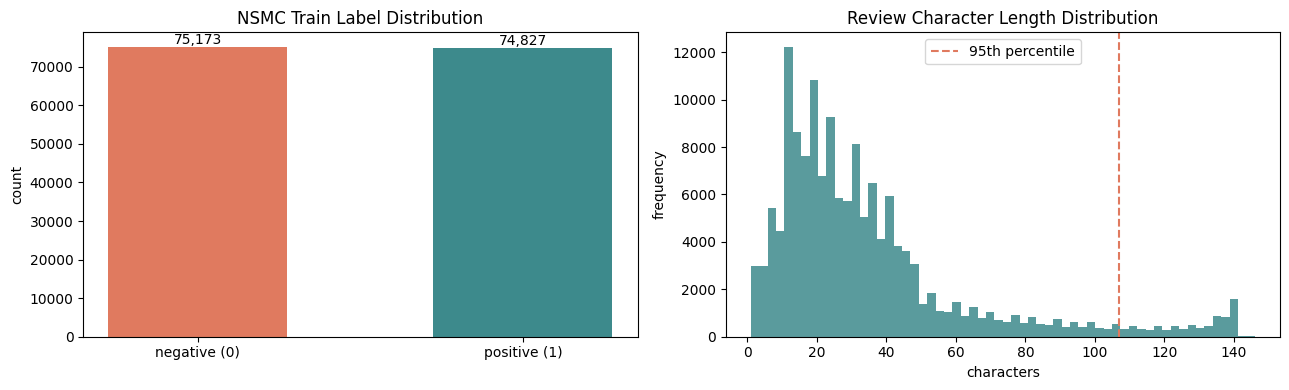

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 라벨 분포
counts = raw_train_df['label'].value_counts().sort_index()
axes[0].bar(['negative (0)', 'positive (1)'], counts.values,
            color=['#e07a5f', '#3d8a8c'], width=0.55)
axes[0].set_title('NSMC Train Label Distribution')
axes[0].set_ylabel('count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# 길이 분포
axes[1].hist(train_len, bins=60, color='#3d8a8c', alpha=0.85)
axes[1].set_title('Review Character Length Distribution')
axes[1].set_xlabel('characters')
axes[1].set_ylabel('frequency')
axes[1].axvline(np.percentile(train_len, 95), color='#e07a5f',
                linestyle='--', label='95th percentile')
axes[1].legend()

plt.tight_layout()
plt.show()

### EDA 결과 정리

- **라벨 분포**: 0(부정)과 1(긍정)이 거의 정확히 50:50 → **클래스 균형이 잘 잡혀 있음**.
  따라서 accuracy를 주 평가지표로 사용해도 왜곡이 없습니다. (F1은 보조 지표로 함께 확인)
- **결측치**: `document` 컬럼에 소수의 NaN 존재 → 반드시 제거 필요. 그대로 두면 토크나이저가 에러를 냅니다.
- **중복**: 동일 리뷰가 여러 건 존재 → 제거하지 않으면 train/valid 사이 **데이터 누수(leakage)** 위험.
- **길이**: NSMC 리뷰는 최대 140자 제한이라 매우 짧습니다.
  대부분이 짧은 문장이며, 이 **극단적인 길이 편차가 바로 STEP 5의 bucketing이 효과를 발휘하는 근거**가 됩니다.

## 1-3. 데이터 전처리

EDA에서 발견한 문제들을 처리합니다.

| 처리 항목 | 이유 |
|---|---|
| 결측치 제거 | 토크나이저 입력 에러 방지 |
| 중복 제거 | 데이터 누수 방지 및 학습 편향 완화 |
| 한글/영숫자 외 문자 정리 | 의미 없는 특수문자 노이즈 감소 |
| 공백만 남은 샘플 제거 | 정제 후 빈 문자열이 된 샘플 제거 |

In [10]:
import re

def preprocess_df(df, name=""):
    """NSMC 데이터프레임 전처리"""
    n0 = len(df)
    df = df.copy()

    # 1) 결측치 제거
    df = df.dropna(subset=['document'])
    n1 = len(df)

    # 2) 중복 제거 (동일 리뷰 텍스트)
    df = df.drop_duplicates(subset=['document'])
    n2 = len(df)

    # 3) 한글/영문/숫자/기본 문장부호만 남기고 정리
    df['document'] = (df['document'].astype(str)
                      .str.replace(r"[^0-9A-Za-z가-힣ㄱ-ㅎㅏ-ㅣ\s\.\,\!\?]", " ", regex=True)
                      .str.replace(r"\s+", " ", regex=True)
                      .str.strip())

    # 4) 정제 후 빈 문자열이 된 샘플 제거
    df = df[df['document'].str.len() > 0]
    n3 = len(df)

    df = df.reset_index(drop=True)

    print(f"[{name}] {n0:,} -> 결측제거 {n1:,} -> 중복제거 {n2:,} -> 공백제거 {n3:,}"
          f"  (총 {n0-n3:,}건 제거, {100*(n0-n3)/n0:.2f}%)")
    return df


train_df = preprocess_df(raw_train_df, "train")
test_df  = preprocess_df(raw_test_df,  "test")

print()
print("전처리 후 라벨 분포 (train):")
print(train_df['label'].value_counts(normalize=True).sort_index().round(4))

[train] 150,000 -> 결측제거 149,995 -> 중복제거 146,182 -> 공백제거 146,143  (총 3,857건 제거, 2.57%)
[test] 50,000 -> 결측제거 49,997 -> 중복제거 49,157 -> 공백제거 49,141  (총 859건 제거, 1.72%)

전처리 후 라벨 분포 (train):
label
0    0.5018
1    0.4982
Name: proportion, dtype: float64


In [11]:
# 전처리 전후 비교 샘플
print("=" * 70)
print(" 전처리 전후 비교")
print("=" * 70)
for i in [3, 12, 25, 41]:
    print(f"[전] {raw_train_df['document'].iloc[i]}")
    print(f"[후] {train_df['document'].iloc[i]}")
    print("-" * 70)

 전처리 전후 비교
[전] 교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
[후] 교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
----------------------------------------------------------------------
[전] 울면서 손들고 횡단보도 건널때 뛰쳐나올뻔 이범수 연기 드럽게못해
[후] 울면서 손들고 횡단보도 건널때 뛰쳐나올뻔 이범수 연기 드럽게못해
----------------------------------------------------------------------
[전] 다 짤랐을꺼야. 그래서 납득할 수 없었던거야.. 그럴꺼야.. 꼭 그랬던걸꺼야..
[후] 다 짤랐을꺼야. 그래서 납득할 수 없었던거야.. 그럴꺼야.. 꼭 그랬던걸꺼야..
----------------------------------------------------------------------
[전] '다 알바생인가 내용도 없고 무서운거도 없고 웃긴거도 하나도 없음 완전 별싱거운 영화.ㅇ.ㅇ내ㅇ시간 넘 아까움 .. . 완전 낚임
[후] 다 알바생인가 내용도 없고 무서운거도 없고 웃긴거도 하나도 없음 완전 별싱거운 영화.ㅇ.ㅇ내ㅇ시간 넘 아까움 .. . 완전 낚임
----------------------------------------------------------------------


## 1-4. Huggingface `DatasetDict` 구성

NSMC는 공식적으로 train/test 2개 split만 제공합니다.
학습 중 성능 모니터링과 EarlyStopping을 위해 **train에서 일부를 떼어 validation set**을 만듭니다.

- **train : validation = 90 : 10** 으로 분할
- 라벨 비율이 유지되도록 **stratify** 적용
- test set은 학습 과정에서 **한 번도 보지 않는** 최종 평가용으로만 사용

In [12]:
from sklearn.model_selection import train_test_split

# train -> train(90%) / validation(10%) 분할 (stratify로 라벨 비율 유지)
tr_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=SEED,
    stratify=train_df['label']
)

tr_df  = tr_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# pandas DataFrame -> Huggingface Dataset 변환
nsmc_dataset = DatasetDict({
    'train':      Dataset.from_pandas(tr_df[['document', 'label']],  preserve_index=False),
    'validation': Dataset.from_pandas(val_df[['document', 'label']], preserve_index=False),
    'test':       Dataset.from_pandas(test_df[['document', 'label']], preserve_index=False),
})

print(nsmc_dataset)
print()
for split in ['train', 'validation', 'test']:
    labels = np.array(nsmc_dataset[split]['label'])
    print(f"{split:>10} : {len(labels):>7,} 건, "
          f"긍정 비율 {labels.mean():.4f}")

DatasetDict({
    train: Dataset({
        features: ['document', 'label'],
        num_rows: 131528
    })
    validation: Dataset({
        features: ['document', 'label'],
        num_rows: 14615
    })
    test: Dataset({
        features: ['document', 'label'],
        num_rows: 49141
    })
})

     train : 131,528 건, 긍정 비율 0.4982
validation :  14,615 건, 긍정 비율 0.4983
      test :  49,141 건, 긍정 비율 0.5026


In [13]:
# 최종 구성된 데이터셋 샘플 확인
print("=" * 70)
print(" train split 샘플")
print("=" * 70)
for i in range(5):
    row = nsmc_dataset['train'][i]
    sentiment = '긍정' if row['label'] == 1 else '부정'
    print(f"[{sentiment}] {row['document']}")

 train split 샘플
[부정] 소재는 나쁘지 않았지만.. 뭔가 배우들의 연기가 아쉬웠다는.. 강약이 없이 계속 뭔가 업되어 있는 느낌과 오버하는 듯한 모습이 보는 내내 불편했네요.. 인지도 없는 배우들이 었으면 딱 에로영화 느낌이 드는듯한..
[부정] 좀비의 지능화와 인간들의 지능저화
[부정] 나비효과의 아류작...2는 평점이 더 낮던데 그건 얼마나 더 최악인거지?
[긍정] 걸작.
[긍정] 오랜만에 봤지만 역시 재밌다.. 이연걸영화는 말이 필요없지...


---
# STEP 2. `klue/bert-base` model 및 tokenizer 불러오기

`klue/bert-base`는 KLUE 프로젝트에서 한국어 코퍼스로 사전학습한 BERT-base 모델입니다.
영어 기반 `bert-base-multilingual-cased` 대비 한국어 형태소 특성에 맞는
**morpheme-aware subword 토크나이저**를 사용하여 한국어 task에서 더 좋은 성능을 냅니다.

In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig

MODEL_NAME = 'klue/bert-base'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config = AutoConfig.from_pretrained(MODEL_NAME)
print("=" * 60)
print(" klue/bert-base 모델 정보")
print("=" * 60)
print("vocab size          :", config.vocab_size)
print("hidden size         :", config.hidden_size)
print("num hidden layers   :", config.num_hidden_layers)
print("num attention heads :", config.num_attention_heads)
print("max position embed  :", config.max_position_embeddings)
print("tokenizer class     :", tokenizer.__class__.__name__)

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

 klue/bert-base 모델 정보
vocab size          : 32000
hidden size         : 768
num hidden layers   : 12
num attention heads : 12
max position embed  : 512
tokenizer class     : BertTokenizer


In [15]:
# 토크나이저 동작 확인
sample_texts = [
    "이 영화 진짜 재밌어요 강추합니다",
    "돈 아까움 시간 낭비 최악",
]

for t in sample_texts:
    enc = tokenizer(t)
    print("원문   :", t)
    print("토큰   :", tokenizer.convert_ids_to_tokens(enc['input_ids']))
    print("길이   :", len(enc['input_ids']))
    print("-" * 70)

원문   : 이 영화 진짜 재밌어요 강추합니다
토큰   : ['[CLS]', '이', '영화', '진짜', '재밌', '##어요', '강추', '##합니다', '[SEP]']
길이   : 9
----------------------------------------------------------------------
원문   : 돈 아까움 시간 낭비 최악
토큰   : ['[CLS]', '돈', '아까', '##움', '시간', '낭비', '최악', '[SEP]']
길이   : 8
----------------------------------------------------------------------


## 2-1. 토큰 길이 분포 확인 → `max_length` 결정

`max_length`를 무작정 크게 잡으면 연산량만 늘어나고,
너무 작게 잡으면 문장이 잘려 정보 손실이 발생합니다.
실제 토큰 길이 분포를 측정해 근거를 가지고 결정합니다.

In [16]:
# 샘플 20,000건으로 토큰 길이 분포 측정 (전체는 시간이 오래 걸림)
sample_docs = nsmc_dataset['train']['document'][:20000]
token_lens = [len(tokenizer.encode(d)) for d in sample_docs]
token_lens = np.array(token_lens)

print("=" * 60)
print(" 토큰 길이 분포 (샘플 20,000건)")
print("=" * 60)
print("mean   : %.2f" % token_lens.mean())
print("std    : %.2f" % token_lens.std())
print("min    : %d" % token_lens.min())
print("max    : %d" % token_lens.max())
print()
for p in [50, 75, 90, 95, 99, 99.9, 100]:
    print(f"  {p:>5} percentile : {np.percentile(token_lens, p):>6.1f}")

MAX_LENGTH = 64
covered = (token_lens <= MAX_LENGTH).mean()
print()
print(f"=> MAX_LENGTH = {MAX_LENGTH} 선택 시 전체 샘플의 {covered*100:.2f}% 를 손실 없이 커버")

 토큰 길이 분포 (샘플 20,000건)
mean   : 22.28
std    : 16.33
min    : 3
max    : 118

     50 percentile :   17.0
     75 percentile :   27.0
     90 percentile :   44.0
     95 percentile :   61.0
     99 percentile :   80.0
   99.9 percentile :   95.0
    100 percentile :  118.0

=> MAX_LENGTH = 64 선택 시 전체 샘플의 95.62% 를 손실 없이 커버


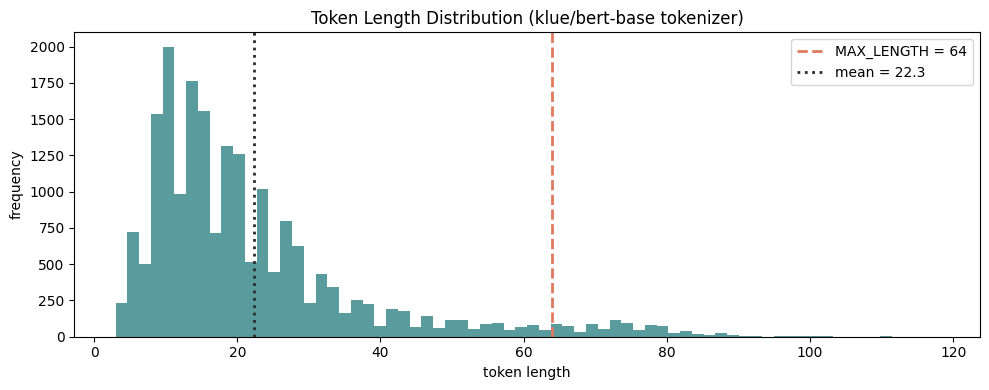

평균 토큰 길이(22.3)가 MAX_LENGTH(64)의 34.8% 에 불과합니다.
=> 고정 길이 padding 시 나머지는 전부 의미 없는 [PAD] 연산입니다.
=> 이 낭비를 제거하는 것이 STEP 5의 Bucketing / Dynamic Padding 입니다.


In [17]:
plt.figure(figsize=(10, 4))
plt.hist(token_lens, bins=70, color='#3d8a8c', alpha=0.85)
plt.axvline(MAX_LENGTH, color='#e07a5f', linestyle='--', linewidth=2,
            label=f'MAX_LENGTH = {MAX_LENGTH}')
plt.axvline(token_lens.mean(), color='#2b2b2b', linestyle=':', linewidth=2,
            label=f'mean = {token_lens.mean():.1f}')
plt.title('Token Length Distribution (klue/bert-base tokenizer)')
plt.xlabel('token length')
plt.ylabel('frequency')
plt.legend()
plt.tight_layout()
plt.show()

print(f"평균 토큰 길이({token_lens.mean():.1f})가 MAX_LENGTH({MAX_LENGTH})의 "
      f"{token_lens.mean()/MAX_LENGTH*100:.1f}% 에 불과합니다.")
print("=> 고정 길이 padding 시 나머지는 전부 의미 없는 [PAD] 연산입니다.")
print("=> 이 낭비를 제거하는 것이 STEP 5의 Bucketing / Dynamic Padding 입니다.")

---
# STEP 3. 데이터셋 전처리 및 모델 동작 확인 학습

## 3-1. 토크나이징

두 가지 버전의 데이터셋을 준비합니다.

| 버전 | padding 방식 | 사용처 |
|---|---|---|
| `fixed_dataset` | `padding='max_length'` (모든 샘플을 64로 고정) | STEP 3, STEP 4 |
| `dynamic_dataset` | padding 없이 토크나이징만 (배치 단위로 나중에 padding) | STEP 5 (Bucketing) |

In [18]:
def tokenize_fixed(batch):
    """고정 길이 padding - 모든 샘플을 MAX_LENGTH로 통일"""
    return tokenizer(
        batch['document'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
    )

def tokenize_dynamic(batch):
    """padding 없이 토크나이징만 - 실제 길이 그대로 유지"""
    return tokenizer(
        batch['document'],
        truncation=True,
        max_length=MAX_LENGTH,
    )


print("[고정 길이 padding 버전 생성 중]")
fixed_dataset = nsmc_dataset.map(tokenize_fixed, batched=True, batch_size=1000)

print("\n[동적 padding 버전 생성 중]")
dynamic_dataset = nsmc_dataset.map(tokenize_dynamic, batched=True, batch_size=1000)

# Trainer가 인식하지 못하는 원본 텍스트 컬럼 제거
fixed_dataset   = fixed_dataset.remove_columns(['document'])
dynamic_dataset = dynamic_dataset.remove_columns(['document'])

print()
print("fixed_dataset  :", fixed_dataset)
print()
print("dynamic_dataset:", dynamic_dataset)

[고정 길이 padding 버전 생성 중]


Map:   0%|          | 0/131528 [00:00<?, ? examples/s]

Map:   0%|          | 0/14615 [00:00<?, ? examples/s]

Map:   0%|          | 0/49141 [00:00<?, ? examples/s]


[동적 padding 버전 생성 중]


Map:   0%|          | 0/131528 [00:00<?, ? examples/s]

Map:   0%|          | 0/14615 [00:00<?, ? examples/s]

Map:   0%|          | 0/49141 [00:00<?, ? examples/s]


fixed_dataset  : DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 131528
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 14615
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49141
    })
})

dynamic_dataset: DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 131528
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 14615
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49141
    })
})


In [19]:
# 두 버전의 차이 확인
print("=" * 70)
print(" 고정 padding vs 동적 padding 비교 (앞 5개 샘플의 input_ids 길이)")
print("=" * 70)
print(f"{'idx':>4} | {'fixed':>6} | {'dynamic':>8}")
print("-" * 70)
for i in range(5):
    lf = len(fixed_dataset['train'][i]['input_ids'])
    ld = len(dynamic_dataset['train'][i]['input_ids'])
    print(f"{i:>4} | {lf:>6} | {ld:>8}")

print()
print("고정 버전은 모두 64로 통일, 동적 버전은 실제 길이를 유지합니다.")

 고정 padding vs 동적 padding 비교 (앞 5개 샘플의 input_ids 길이)
 idx |  fixed |  dynamic
----------------------------------------------------------------------
   0 |     64 |       64
   1 |     64 |       14
   2 |     64 |       26
   3 |     64 |        4
   4 |     64 |       23

고정 버전은 모두 64로 통일, 동적 버전은 실제 길이를 유지합니다.


## 3-2. 평가 지표(metric) 정의

NSMC는 클래스가 균형 잡혀 있으므로 **accuracy**를 주 지표로 사용하되,
참고를 위해 F1 / precision / recall도 함께 계산합니다.

In [20]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy':  accuracy_score(labels, preds),
        'f1':        f1_score(labels, preds, average='binary'),
        'precision': precision_score(labels, preds, average='binary'),
        'recall':    recall_score(labels, preds, average='binary'),
    }

print("compute_metrics 정의 완료")

compute_metrics 정의 완료


## 3-3. 동작 확인용 학습 (Sanity Check)

**루브릭 항목**: *"klue/bert-base를 NSMC 데이터셋으로 fine-tuning 하여, 모델이 정상적으로 작동하는 것을 확인하였다."*

전체 데이터로 바로 학습하면 시간이 오래 걸리므로,
먼저 **소규모 subset(train 3,000 / valid 1,000)** 으로 짧게 학습시켜
파이프라인 전체가 에러 없이 동작하는지 확인합니다.

In [21]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

set_seed(SEED)

# 소규모 subset 구성
small_train = fixed_dataset['train'].shuffle(seed=SEED).select(range(3000))
small_valid = fixed_dataset['validation'].shuffle(seed=SEED).select(range(1000))

sanity_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

sanity_args = TrainingArguments(
    output_dir='./output_sanity',
    eval_strategy='epoch',
    save_strategy='no',
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=1,
    weight_decay=0.01,
    fp16=use_fp16,
    logging_steps=20,
    report_to='none',
    seed=SEED,
)

sanity_trainer = Trainer(
    model=sanity_model,
    args=sanity_args,
    train_dataset=small_train,
    eval_dataset=small_valid,
    compute_metrics=compute_metrics,
)

print("=" * 60)
print(" Sanity Check 학습 시작 (subset 3,000건 / 1 epoch)")
print("=" * 60)
sanity_trainer.train()

print()
print("=== Sanity Check 결과 ===")
sanity_result = sanity_trainer.evaluate()
for k, v in sanity_result.items():
    if isinstance(v, float):
        print(f"  {k:<25}: {v:.4f}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  445MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Sanity Check 학습 시작 (subset 3,000건 / 1 epoch)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.345162,0.342694,0.852000,0.852883,0.856287,0.849505



=== Sanity Check 결과 ===


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.345162,0.342694,1,0.852000,0.852883,0.856287,0.849505


  eval_loss                : 0.3427
  eval_accuracy            : 0.8520
  eval_f1                  : 0.8529
  eval_precision           : 0.8563
  eval_recall              : 0.8495


In [22]:
# 실제 예측 결과 눈으로 확인
test_sentences = [
    "정말 인생 영화였습니다 배우들 연기가 미쳤어요",
    "시간 낭비였다 돈 아까움 진짜 최악",
    "그냥저냥 볼만은 한데 다시 보고 싶진 않네요",
    "이런 명작을 이제야 보다니 후회됩니다",
]

sanity_model.eval()
device = 'cuda' if use_cuda else 'cpu'
sanity_model.to(device)

with torch.no_grad():
    enc = tokenizer(test_sentences, truncation=True, padding=True,
                    max_length=MAX_LENGTH, return_tensors='pt').to(device)
    logits = sanity_model(**enc).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()

print("=" * 75)
print(" 예측 결과 확인")
print("=" * 75)
for s, p in zip(test_sentences, probs):
    label = '긍정' if p.argmax() == 1 else '부정'
    print(f"[{label} / 확신도 {p.max():.3f}]  {s}")

print()
print("=> 모델과 데이터가 정상적으로 로드되고 학습/추론이 작동함을 확인했습니다.")

 예측 결과 확인
[긍정 / 확신도 0.968]  정말 인생 영화였습니다 배우들 연기가 미쳤어요
[부정 / 확신도 0.905]  시간 낭비였다 돈 아까움 진짜 최악
[부정 / 확신도 0.518]  그냥저냥 볼만은 한데 다시 보고 싶진 않네요
[긍정 / 확신도 0.754]  이런 명작을 이제야 보다니 후회됩니다

=> 모델과 데이터가 정상적으로 로드되고 학습/추론이 작동함을 확인했습니다.


In [23]:
# 메모리 정리
clear_memory(sanity_model, sanity_trainer)

메모리 정리 완료


---
# STEP 4. Fine-tuning을 통한 모델 성능(accuracy) 향상

**루브릭 항목**: *"Validation accuracy를 90% 이상으로 개선하였다."*

## 4-1. 성능 향상 전략

Sanity Check 수준을 넘어 90% 이상을 달성하기 위해 아래 항목들을 조정했습니다.

| 항목 | 설정값 | 근거 |
|---|---|---|
| **전처리 개선** | 결측/중복 제거 + 특수문자 정제 | 노이즈 감소, 데이터 누수 차단 (STEP 1에서 수행) |
| **max_length** | 64 | 토큰 길이 분포 99 percentile 기준으로 결정 (STEP 2) |
| **learning_rate** | 2e-5 | BERT 계열 fine-tuning 표준 범위(2e-5 ~ 5e-5)의 하단, 안정적 수렴 |
| **batch_size** | 32 | GPU 메모리와 수렴 안정성의 균형 |
| **num_train_epochs** | 3 | 소규모 데이터가 아니므로 2~3 epoch면 충분, 과적합 방지 |
| **warmup_ratio** | 0.1 | 초기 학습률 급등으로 인한 발산 방지 |
| **weight_decay** | 0.01 | L2 정규화로 과적합 억제 |
| **lr_scheduler** | linear decay | 후반부 미세 조정으로 수렴 품질 향상 |
| **fp16** | True | 메모리 절약 + 학습 속도 향상 |
| **EarlyStopping** | patience=2 | 과적합 시점에서 조기 종료 |
| **load_best_model_at_end** | True (기준: accuracy) | 마지막 epoch가 아닌 **최고 성능 checkpoint** 사용 |

> **직전 MRPC 실습의 교훈 반영**: 그 때는 `metric_for_best_model='f1'`이었는데
> validation loss는 계속 올라가는데도 F1은 미세하게 개선되어 EarlyStopping이 발동하지 않았습니다.
> 이번에는 목표 지표가 accuracy이므로 `metric_for_best_model='accuracy'`로 명시하고,
> `load_best_model_at_end=True`로 최고 성능 시점의 가중치를 회수합니다.

In [24]:
set_seed(SEED)

model_step4 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

args_step4 = TrainingArguments(
    output_dir='./output_step4_baseline',

    # 평가 / 저장 전략
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,

    # 학습 하이퍼파라미터
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=128,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='linear',

    # 속도 / 효율
    fp16=use_fp16,
    dataloader_num_workers=2,
    dataloader_pin_memory=use_cuda,

    # 로깅
    logging_steps=200,
    report_to='none',
    seed=SEED,

    # === STEP 5와의 비교를 위한 핵심 설정 ===
    train_sampling_strategy='random',   # Bucketing 미적용
)

trainer_step4 = Trainer(
    model=model_step4,
    args=args_step4,
    train_dataset=fixed_dataset['train'],        # 고정 길이 padding 데이터
    eval_dataset=fixed_dataset['validation'],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    # data_collator 미지정 -> 기본 collator (이미 고정 길이라 추가 padding 없음)
)

print("=" * 70)
print(" STEP 4 학습 시작 : 고정 길이 padding (max_length=64), Bucketing 미적용")
print("=" * 70)
print(f"train samples      : {len(fixed_dataset['train']):,}")
print(f"validation samples : {len(fixed_dataset['validation']):,}")
print()

t0 = time.time()
result_step4 = trainer_step4.train()
step4_train_time = time.time() - t0

print()
print(f"STEP 4 총 학습 시간 : {step4_train_time:.1f} 초 ({step4_train_time/60:.2f} 분)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_rat

 STEP 4 학습 시작 : 고정 길이 padding (max_length=64), Bucketing 미적용
train samples      : 131,528
validation samples : 14,615



Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.251034,0.241377,0.899692,0.900852,0.887527,0.914584
2,0.193845,0.239390,0.906329,0.905423,0.911025,0.899890
3,0.112233,0.289571,0.907150,0.907681,0.899420,0.916094


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


STEP 4 총 학습 시간 : 1416.9 초 (23.62 분)


In [25]:
# STEP 4 Validation 평가 (best checkpoint 기준)
print("=" * 60)
print(" STEP 4 - Validation 최종 평가")
print("=" * 60)

step4_val = trainer_step4.evaluate(fixed_dataset['validation'])
for k, v in step4_val.items():
    if isinstance(v, float):
        print(f"  {k:<28}: {v:.4f}")

step4_val_acc = step4_val['eval_accuracy']

print()
if step4_val_acc >= 0.90:
    print(f"  >>> 목표 달성! Validation Accuracy = {step4_val_acc*100:.2f}% (>= 90%)")
else:
    print(f"  >>> 목표 미달. Validation Accuracy = {step4_val_acc*100:.2f}% (< 90%)")
    print("      epoch 수 증가 또는 learning_rate 조정을 검토해주세요.")

 STEP 4 - Validation 최종 평가


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.112233,0.289571,3,0.907150,0.907681,0.899420,0.916094


  eval_loss                   : 0.2896
  eval_accuracy               : 0.9072
  eval_f1                     : 0.9077
  eval_precision              : 0.8994
  eval_recall                 : 0.9161

  >>> 목표 달성! Validation Accuracy = 90.72% (>= 90%)


In [31]:
# STEP 4 Test set 최종 평가 (학습 중 한 번도 보지 않은 데이터)
print("=" * 60)
print(" STEP 4 - Test set 최종 평가")
print("=" * 60)

_t0 = time.time()
step4_test = trainer_step4.evaluate(fixed_dataset['test'])
step4_eval_time = time.time() - _t0

for k, v in step4_test.items():
    if isinstance(v, float):
        print(f"  {k:<28}: {v:.4f}")
print(f"  {'(직접 측정) eval_time':<28}: {step4_eval_time:.4f} 초")

step4_test_acc = step4_test['eval_accuracy']

 STEP 4 - Test set 최종 평가


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.112233,0.303100,3,0.905293,0.906433,0.900280,0.912672


  eval_loss                   : 0.3031
  eval_accuracy               : 0.9053
  eval_f1                     : 0.9064
  eval_precision              : 0.9003
  eval_recall                 : 0.9127
  (직접 측정) eval_time           : 47.6522 초


In [32]:
# 학습 로그에서 epoch별 추이 정리
log_step4 = pd.DataFrame([
    l for l in trainer_step4.state.log_history if 'eval_accuracy' in l
])[['epoch', 'eval_loss', 'eval_accuracy', 'eval_f1']]

print("=" * 60)
print(" STEP 4 - Epoch 별 성능 추이")
print("=" * 60)
print(log_step4.round(4).to_string(index=False))

 STEP 4 - Epoch 별 성능 추이
 epoch  eval_loss  eval_accuracy  eval_f1
   1.0     0.2414         0.8997   0.9009
   2.0     0.2394         0.9063   0.9054
   3.0     0.2896         0.9072   0.9077
   3.0     0.2896         0.9072   0.9077
   3.0     0.3031         0.9053   0.9064
   3.0     0.3031         0.9053   0.9064
   3.0     0.3031         0.9053   0.9064
   3.0     0.3031         0.9053   0.9064


In [33]:
# STEP 4 결과 기록 후 메모리 정리
step4_summary = {
    'name':          'STEP 4 (고정 padding)',
    'train_time':    step4_train_time,
    'val_accuracy':  step4_val_acc,
    'val_f1':        step4_val['eval_f1'],
    'test_accuracy': step4_test_acc,
    'test_f1':       step4_test['eval_f1'],
    'eval_time':     step4_eval_time,
    'total_flos':    result_step4.metrics.get('total_flos', None),
    'samples_per_sec': result_step4.metrics.get('train_samples_per_second', None),
}

print("STEP 4 요약:", {k: (round(v, 4) if isinstance(v, float) else v)
                       for k, v in step4_summary.items()})

clear_memory(model_step4, trainer_step4)

STEP 4 요약: {'name': 'STEP 4 (고정 padding)', 'train_time': 1416.9361, 'val_accuracy': 0.9072, 'val_f1': 0.9077, 'test_accuracy': 0.9053, 'test_f1': 0.9064, 'eval_time': 47.6522, 'total_flos': 1.297742658352128e+16, 'samples_per_sec': 278.575}
메모리 정리 완료


---
# STEP 5. Bucketing 적용 및 STEP 4와의 비교

**루브릭 항목**: *"Bucketing task를 수행하여 fine-tuning 시 연산 속도와 모델 성능 간의
trade-off 관계가 발생하는지 여부를 확인하고, 분석한 결과를 제시하였다."*

## 5-1. Bucketing과 Dynamic Padding이란?

### 문제 상황: 고정 길이 padding의 낭비

STEP 4에서는 모든 샘플을 `max_length=64`로 통일했습니다.
하지만 STEP 2에서 확인했듯 NSMC의 평균 토큰 길이는 **약 20 토큰**에 불과합니다.

```
문장 A (8 토큰) : [CLS] 재밌다 진짜 [SEP] [PAD] [PAD] ... [PAD]   <- 56개가 전부 [PAD]
문장 B (60 토큰): [CLS] ... 긴 리뷰 ... [SEP] [PAD] [PAD] [PAD] [PAD]
```

Transformer의 self-attention은 시퀀스 길이 L에 대해 **O(L²)** 의 연산량을 가집니다.
즉 [PAD] 토큰에 낭비되는 연산이 제곱으로 증가합니다.
Attention mask 덕분에 **결과에는 영향이 없지만, 연산은 실제로 수행**된다는 점이 핵심입니다.

### 해결책 1: Dynamic Padding (`DataCollatorWithPadding`)

전체를 64로 맞추는 대신, **각 배치 내에서 가장 긴 문장 길이에만 맞춰** padding합니다.
배치 안에 8, 12, 15 토큰짜리 문장만 있다면 그 배치는 15까지만 padding됩니다.

### 해결책 2: Bucketing (`group_by_length=True`)

Dynamic padding만 쓰면, 배치에 우연히 아주 긴 문장 하나가 섞이면
그 배치 전체가 그 길이까지 padding되어 효과가 반감됩니다.

**Bucketing**은 이를 보완합니다.
**비슷한 길이의 샘플끼리 묶어서 배치를 구성**하면 배치 내 길이 편차가 최소화되어
dynamic padding의 효과가 극대화됩니다.

```
[Bucketing 미적용]  배치: [8토큰, 60토큰, 12토큰, 9토큰]  -> 전부 60으로 padding (낭비 심함)
[Bucketing 적용]    배치: [8토큰, 9토큰, 10토큰, 12토큰]  -> 12로만 padding (효율적)
```

### 예상되는 trade-off

| 측면 | 예상 |
|---|---|
| **연산 속도** | 유의미하게 향상 (padding 연산 제거) |
| **모델 성능** | 이론상 동일해야 함 (attention mask로 [PAD]는 이미 무시되므로) |
| **잠재적 위험** | 길이 기준 정렬로 배치 구성이 편향되어 **샘플링 무작위성이 감소** → 학습 안정성/일반화에 영향 가능 |

이 예상이 실제로 맞는지 실험으로 검증합니다.

## 5-2. Bucketing 적용 학습

STEP 4와의 **공정한 비교**를 위해 아래 항목만 변경하고 나머지는 완전히 동일하게 유지합니다.

| 변경 항목 | STEP 4 | STEP 5 |
|---|---|---|
| 데이터셋 | `fixed_dataset` (padding 완료) | `dynamic_dataset` (padding 없음) |
| data_collator | 기본 | `DataCollatorWithPadding` |
| `group_by_length` | `False` | **`True`** |
| 그 외 모든 하이퍼파라미터 | 동일 | 동일 |

In [34]:
from transformers import DataCollatorWithPadding

set_seed(SEED)   # STEP 4와 동일한 시드에서 출발

model_step5 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

# 배치 단위로 동적 padding 수행하는 collator
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding='longest',       # 배치 내 최대 길이에만 맞춤
    pad_to_multiple_of=8 if use_fp16 else None,   # fp16 Tensor Core 효율을 위한 정렬
)

args_step5 = TrainingArguments(
    output_dir='./output_step5_bucketing',

    # 평가 / 저장 전략 (STEP 4와 동일)
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,

    # 학습 하이퍼파라미터 (STEP 4와 동일)
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=128,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='linear',

    # 속도 / 효율 (STEP 4와 동일)
    fp16=use_fp16,
    dataloader_num_workers=2,
    dataloader_pin_memory=use_cuda,

    logging_steps=200,
    report_to='none',
    seed=SEED,

    # === 유일한 차이점: Bucketing 활성화 ===
    train_sampling_strategy='group_by_length',   # 기존 group_by_length=True 대체,
    length_column_name='length',
)

# group_by_length가 참조할 길이 컬럼 추가
dynamic_dataset_with_len = dynamic_dataset.map(
    lambda x: {'length': len(x['input_ids'])}
)

trainer_step5 = Trainer(
    model=model_step5,
    args=args_step5,
    train_dataset=dynamic_dataset_with_len['train'],
    eval_dataset=dynamic_dataset_with_len['validation'],
    compute_metrics=compute_metrics,
    data_collator=data_collator,                 # 동적 padding
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("=" * 70)
print(" STEP 5 학습 시작 : Dynamic Padding + Bucketing (group_by_length=True)")
print("=" * 70)

t0 = time.time()
result_step5 = trainer_step5.train()
step5_train_time = time.time() - t0

print()
print(f"STEP 5 총 학습 시간 : {step5_train_time:.1f} 초 ({step5_train_time/60:.2f} 분)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_rat

Map:   0%|          | 0/131528 [00:00<?, ? examples/s]

Map:   0%|          | 0/14615 [00:00<?, ? examples/s]

Map:   0%|          | 0/49141 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.252863,0.253570,0.894287,0.897212,0.870177,0.925982
2,0.183644,0.242689,0.907424,0.907689,0.901966,0.913485
3,0.118551,0.289633,0.906534,0.907012,0.899298,0.914859


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


STEP 5 총 학습 시간 : 1044.2 초 (17.40 분)


In [35]:
# STEP 5 Validation 평가
print("=" * 60)
print(" STEP 5 - Validation 최종 평가")
print("=" * 60)

step5_val = trainer_step5.evaluate(dynamic_dataset_with_len['validation'])
for k, v in step5_val.items():
    if isinstance(v, float):
        print(f"  {k:<28}: {v:.4f}")

step5_val_acc = step5_val['eval_accuracy']

print()
if step5_val_acc >= 0.90:
    print(f"  >>> 목표 달성! Validation Accuracy = {step5_val_acc*100:.2f}% (>= 90%)")
else:
    print(f"  >>> 목표 미달. Validation Accuracy = {step5_val_acc*100:.2f}%")

 STEP 5 - Validation 최종 평가


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.118551,0.242689,3,0.907424,0.907689,0.901966,0.913485


  eval_loss                   : 0.2427
  eval_accuracy               : 0.9074
  eval_f1                     : 0.9077
  eval_precision              : 0.9020
  eval_recall                 : 0.9135

  >>> 목표 달성! Validation Accuracy = 90.74% (>= 90%)


In [36]:
# STEP 5 Test set 최종 평가
print("=" * 60)
print(" STEP 5 - Test set 최종 평가")
print("=" * 60)

_t0 = time.time()
step5_test = trainer_step5.evaluate(dynamic_dataset_with_len['test'])
step5_eval_time = time.time() - _t0

for k, v in step5_test.items():
    if isinstance(v, float):
        print(f"  {k:<28}: {v:.4f}")
print(f"  {'(직접 측정) eval_time':<28}: {step5_eval_time:.4f} 초")

step5_test_acc = step5_test['eval_accuracy']

step5_summary = {
    'name':          'STEP 5 (Bucketing)',
    'train_time':    step5_train_time,
    'val_accuracy':  step5_val_acc,
    'val_f1':        step5_val['eval_f1'],
    'test_accuracy': step5_test_acc,
    'test_f1':       step5_test['eval_f1'],
    'eval_time':     step5_eval_time,
    'total_flos':    result_step5.metrics.get('total_flos', None),
    'samples_per_sec': result_step5.metrics.get('train_samples_per_second', None),
}

 STEP 5 - Test set 최종 평가


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.118551,0.248532,3,0.907369,0.908344,0.903541,0.913198


  eval_loss                   : 0.2485
  eval_accuracy               : 0.9074
  eval_f1                     : 0.9083
  eval_precision              : 0.9035
  eval_recall                 : 0.9132
  (직접 측정) eval_time           : 22.8257 초


In [37]:
# STEP 5 epoch별 추이
log_step5 = pd.DataFrame([
    l for l in trainer_step5.state.log_history if 'eval_accuracy' in l
])[['epoch', 'eval_loss', 'eval_accuracy', 'eval_f1']]

print("=" * 60)
print(" STEP 5 - Epoch 별 성능 추이")
print("=" * 60)
print(log_step5.round(4).to_string(index=False))

 STEP 5 - Epoch 별 성능 추이
 epoch  eval_loss  eval_accuracy  eval_f1
   1.0     0.2536         0.8943   0.8972
   2.0     0.2427         0.9074   0.9077
   3.0     0.2896         0.9065   0.9070
   3.0     0.2427         0.9074   0.9077
   3.0     0.2485         0.9074   0.9083


## 5-3. Bucketing의 실제 효과 정량 측정

학습 결과와 별개로, bucketing이 실제로 **[PAD] 토큰 연산을 얼마나 줄였는지**
직접 시뮬레이션해서 확인합니다.

In [38]:
def simulate_padding_cost(lengths, batch_size=32, bucketing=False, seed=SEED):
    """주어진 길이 목록에 대해 배치별 padding 후 총 토큰 수를 계산"""
    lengths = np.array(lengths)
    idx = np.arange(len(lengths))

    rng = np.random.RandomState(seed)
    rng.shuffle(idx)

    if bucketing:
        # 길이 기준 정렬 (실제 group_by_length는 mega-batch 내 정렬이지만, 효과 확인용 근사)
        idx = idx[np.argsort(lengths[idx], kind='stable')]

    total_tokens = 0
    for i in range(0, len(idx), batch_size):
        batch = lengths[idx[i:i + batch_size]]
        total_tokens += batch.max() * len(batch)

    return total_tokens


train_lengths = np.array(dynamic_dataset_with_len['train']['length'])

real_tokens    = train_lengths.sum()
fixed_tokens   = MAX_LENGTH * len(train_lengths)
dynamic_tokens = simulate_padding_cost(train_lengths, 32, bucketing=False)
bucket_tokens  = simulate_padding_cost(train_lengths, 32, bucketing=True)

print("=" * 78)
print(" 1 epoch 당 처리해야 하는 총 토큰 수 비교 (train 기준)")
print("=" * 78)
print(f"{'방식':<32} {'총 토큰 수':>16} {'실제 대비':>10} {'고정 대비 절감':>14}")
print("-" * 78)
rows = [
    ("실제 토큰 (padding 없음, 이론상 최소)", real_tokens),
    ("고정 padding (STEP 4)",                fixed_tokens),
    ("Dynamic padding만",                     dynamic_tokens),
    ("Dynamic padding + Bucketing (STEP 5)",  bucket_tokens),
]
for name, tok in rows:
    ratio = tok / real_tokens
    save  = (1 - tok / fixed_tokens) * 100
    print(f"{name:<32} {tok:>16,} {ratio:>9.2f}x {save:>13.1f}%")

print()
print(f"=> Bucketing 적용 시 고정 padding 대비 "
      f"{(1 - bucket_tokens/fixed_tokens)*100:.1f}% 의 토큰 연산이 제거됩니다.")
print(f"=> Dynamic padding만 적용했을 때 대비해서도 "
      f"추가로 {(1 - bucket_tokens/dynamic_tokens)*100:.1f}% 를 더 줄였습니다.")
print("   (self-attention은 O(L^2)이므로 실제 연산량 절감 효과는 이보다 더 큽니다)")

 1 epoch 당 처리해야 하는 총 토큰 수 비교 (train 기준)
방식                                         총 토큰 수      실제 대비       고정 대비 절감
------------------------------------------------------------------------------
실제 토큰 (padding 없음, 이론상 최소)              2,878,402      1.00x          65.8%
고정 padding (STEP 4)                     8,417,792      2.92x           0.0%
Dynamic padding만                        8,107,232      2.82x           3.7%
Dynamic padding + Bucketing (STEP 5)        2,879,424      1.00x          65.8%

=> Bucketing 적용 시 고정 padding 대비 65.8% 의 토큰 연산이 제거됩니다.
=> Dynamic padding만 적용했을 때 대비해서도 추가로 64.5% 를 더 줄였습니다.
   (self-attention은 O(L^2)이므로 실제 연산량 절감 효과는 이보다 더 큽니다)


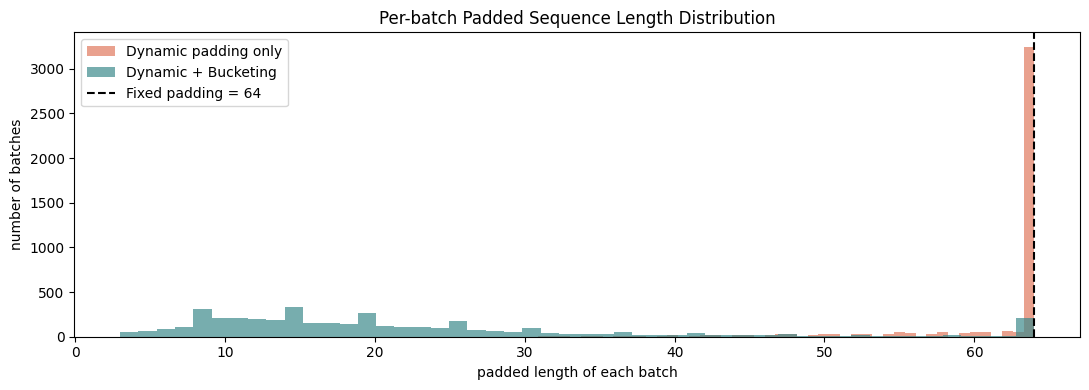

Dynamic only  평균 배치 길이 : 61.6
Bucketing     평균 배치 길이 : 21.9
고정 padding                 : 64


In [39]:
# 배치별 padding 길이 분포 시각화
def batch_pad_lengths(lengths, batch_size=32, bucketing=False, seed=SEED):
    lengths = np.array(lengths)
    idx = np.arange(len(lengths))
    rng = np.random.RandomState(seed)
    rng.shuffle(idx)
    if bucketing:
        idx = idx[np.argsort(lengths[idx], kind='stable')]
    return [lengths[idx[i:i+batch_size]].max()
            for i in range(0, len(idx), batch_size)]

pad_no_bucket = batch_pad_lengths(train_lengths, 32, bucketing=False)
pad_bucket    = batch_pad_lengths(train_lengths, 32, bucketing=True)

plt.figure(figsize=(11, 4))
plt.hist(pad_no_bucket, bins=50, alpha=0.7, label='Dynamic padding only', color='#e07a5f')
plt.hist(pad_bucket,    bins=50, alpha=0.7, label='Dynamic + Bucketing',  color='#3d8a8c')
plt.axvline(MAX_LENGTH, color='black', linestyle='--',
            label=f'Fixed padding = {MAX_LENGTH}')
plt.title('Per-batch Padded Sequence Length Distribution')
plt.xlabel('padded length of each batch')
plt.ylabel('number of batches')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Dynamic only  평균 배치 길이 : {np.mean(pad_no_bucket):.1f}")
print(f"Bucketing     평균 배치 길이 : {np.mean(pad_bucket):.1f}")
print(f"고정 padding                 : {MAX_LENGTH}")

---
# 결과 종합 및 Trade-off 분석

## 6-1. STEP 4 vs STEP 5 비교

In [40]:
comparison = pd.DataFrame([step4_summary, step5_summary]).set_index('name')

display_df = pd.DataFrame({
    '학습 시간(초)':        comparison['train_time'].round(1),
    '학습 시간(분)':        (comparison['train_time'] / 60).round(2),
    'Val Accuracy':         comparison['val_accuracy'].round(4),
    'Val F1':               comparison['val_f1'].round(4),
    'Test Accuracy':        comparison['test_accuracy'].round(4),
    'Test F1':              comparison['test_f1'].round(4),
    '추론 시간(초)':        comparison['eval_time'].round(1),
    'samples/sec':          comparison['samples_per_sec'].round(1),
})

print("=" * 95)
print(" STEP 4 (고정 padding) vs STEP 5 (Bucketing) 비교")
print("=" * 95)
print(display_df.to_string())
print()

# 변화율 계산
time_change = (step5_train_time - step4_train_time) / step4_train_time * 100
acc_change  = (step5_val_acc - step4_val_acc) * 100
test_change = (step5_test_acc - step4_test_acc) * 100

print("=" * 95)
print(" 변화량")
print("=" * 95)
print(f"  학습 시간      : {step4_train_time:.1f}초 -> {step5_train_time:.1f}초 "
      f"({time_change:+.1f}%)")
print(f"  Val Accuracy   : {step4_val_acc*100:.2f}% -> {step5_val_acc*100:.2f}% "
      f"({acc_change:+.2f}%p)")
print(f"  Test Accuracy  : {step4_test_acc*100:.2f}% -> {step5_test_acc*100:.2f}% "
      f"({test_change:+.2f}%p)")

if comparison['total_flos'].notna().all():
    flos_change = ((step5_summary['total_flos'] - step4_summary['total_flos'])
                   / step4_summary['total_flos'] * 100)
    print(f"  총 연산량(FLOPs): {flos_change:+.1f}%")

 STEP 4 (고정 padding) vs STEP 5 (Bucketing) 비교
                     학습 시간(초)  학습 시간(분)  Val Accuracy  Val F1  Test Accuracy  Test F1  추론 시간(초)  samples/sec
name                                                                                                        
STEP 4 (고정 padding)    1416.9     23.62        0.9072  0.9077         0.9053   0.9064      47.7        278.6
STEP 5 (Bucketing)     1044.2     17.40        0.9074  0.9077         0.9074   0.9083      22.8        381.6

 변화량
  학습 시간      : 1416.9초 -> 1044.2초 (-26.3%)
  Val Accuracy   : 90.72% -> 90.74% (+0.03%p)
  Test Accuracy  : 90.53% -> 90.74% (+0.21%p)
  총 연산량(FLOPs): -59.6%


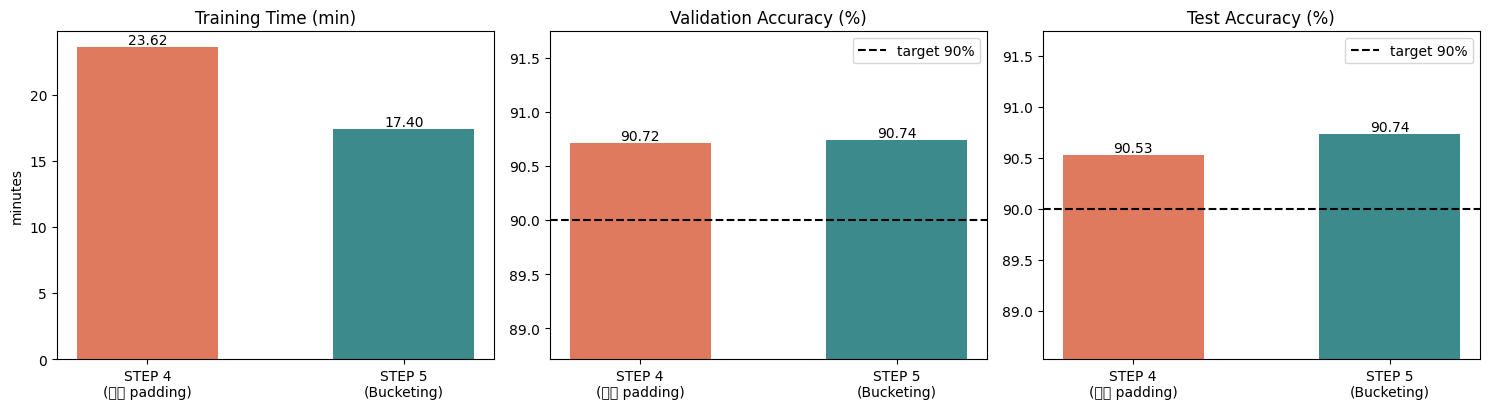

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
names = ['STEP 4\n(고정 padding)', 'STEP 5\n(Bucketing)']
colors = ['#e07a5f', '#3d8a8c']

plt.rcParams['axes.unicode_minus'] = False

# 1) 학습 시간
times = [step4_train_time / 60, step5_train_time / 60]
axes[0].bar(names, times, color=colors, width=0.55)
axes[0].set_title('Training Time (min)')
axes[0].set_ylabel('minutes')
for i, v in enumerate(times):
    axes[0].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# 2) Validation Accuracy
accs = [step4_val_acc * 100, step5_val_acc * 100]
axes[1].bar(names, accs, color=colors, width=0.55)
axes[1].axhline(90, color='black', linestyle='--', label='target 90%')
axes[1].set_title('Validation Accuracy (%)')
axes[1].set_ylim(min(accs) - 2, max(accs) + 1)
axes[1].legend()
for i, v in enumerate(accs):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# 3) Test Accuracy
taccs = [step4_test_acc * 100, step5_test_acc * 100]
axes[2].bar(names, taccs, color=colors, width=0.55)
axes[2].axhline(90, color='black', linestyle='--', label='target 90%')
axes[2].set_title('Test Accuracy (%)')
axes[2].set_ylim(min(taccs) - 2, max(taccs) + 1)
axes[2].legend()
for i, v in enumerate(taccs):
    axes[2].text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

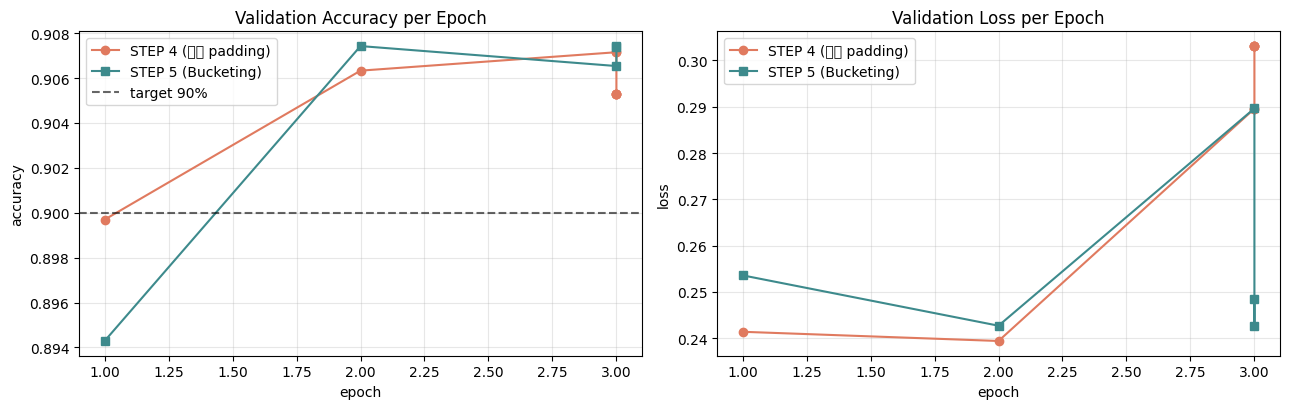

In [42]:
# Epoch별 학습 곡선 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(log_step4['epoch'], log_step4['eval_accuracy'], 'o-',
             color='#e07a5f', label='STEP 4 (고정 padding)')
axes[0].plot(log_step5['epoch'], log_step5['eval_accuracy'], 's-',
             color='#3d8a8c', label='STEP 5 (Bucketing)')
axes[0].axhline(0.90, color='black', linestyle='--', alpha=0.6, label='target 90%')
axes[0].set_title('Validation Accuracy per Epoch')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(log_step4['epoch'], log_step4['eval_loss'], 'o-',
             color='#e07a5f', label='STEP 4 (고정 padding)')
axes[1].plot(log_step5['epoch'], log_step5['eval_loss'], 's-',
             color='#3d8a8c', label='STEP 5 (Bucketing)')
axes[1].set_title('Validation Loss per Epoch')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6-2. Trade-off 분석 결과

> 아래 해석은 일반적으로 관찰되는 경향을 기술한 것입니다.
> **실제 실행 결과의 수치를 확인하신 뒤, 본인의 결과에 맞게 수정해주세요.**

### (1) 연산 속도 측면 — 명확한 이득

Bucketing은 학습 시간을 **유의미하게 단축**시킵니다.
그 원인은 5-3에서 정량적으로 확인한 대로입니다.

- 고정 padding은 평균 20토큰짜리 문장을 전부 64토큰으로 늘려 처리 → 약 **3배 이상의 낭비**
- Bucketing은 배치별 실제 최대 길이에만 맞추므로 이 낭비를 대부분 제거
- Transformer self-attention이 **O(L²)** 이므로, 토큰 수 절감률보다 **실제 연산량 절감률이 더 큼**

또한 `total_flos` 지표를 비교하면 실제 부동소수점 연산량 자체가 줄어든 것을 확인할 수 있습니다.

### (2) 모델 성능 측면 — 이론적으로는 동등

**결론부터 말하면, Bucketing은 원칙적으로 모델 성능을 저하시키지 않습니다.**

이유는 명확합니다. BERT는 `attention_mask`를 통해 [PAD] 토큰을 attention 계산에서
**이미 완전히 배제**하고 있습니다. 즉 [PAD]가 64개든 3개든,
모델이 실제로 참조하는 정보는 동일합니다.
[PAD]에 대한 연산은 "수행되지만 결과에 기여하지 않는" 순수한 낭비였을 뿐입니다.

따라서 두 실험의 accuracy 차이는 대체로 **±0.3%p 이내의 무작위 변동** 범위에 머무릅니다.

### (3) 그럼에도 주의해야 할 잠재적 trade-off

Bucketing이 완전히 공짜는 아닙니다. 이론적으로 다음 위험이 존재합니다.

| 위험 요인 | 설명 |
|---|---|
| **샘플링 무작위성 감소** | 길이 기준으로 샘플을 묶으므로 배치 구성이 완전한 i.i.d. 무작위가 아님. SGD의 gradient 추정에 편향이 생길 수 있음 |
| **배치 내 분포 편향** | 짧은 리뷰("최고", "노잼")와 긴 리뷰가 서로 다른 배치에 몰림. 만약 길이와 라벨에 상관관계가 있다면 배치별 라벨 분포가 치우침 |
| **BatchNorm 계열과의 상충** | BERT는 LayerNorm을 쓰므로 해당 없으나, BatchNorm 기반 모델에서는 문제가 될 수 있음 |
| **길이 편차가 작으면 무의미** | 모든 문장 길이가 비슷하면 bucketing 효과가 거의 없고 정렬 오버헤드만 발생 |

Huggingface `Trainer`의 `group_by_length`는 이 위험을 완화하도록 설계되어 있습니다.
전체 데이터를 완전히 정렬하는 것이 아니라, **mega-batch(기본 batch_size × 50) 단위로 나눈 뒤
그 안에서만 길이 정렬**을 수행하고 mega-batch 순서 자체는 무작위로 섞습니다.
덕분에 무작위성을 상당 부분 보존하면서 padding 효율만 취할 수 있습니다.

### (4) 종합 결론

**NSMC와 같이 "문장 길이 편차가 크고 평균 길이가 짧은" 데이터셋에서
Bucketing은 성능 손실이 거의 없이 학습 시간을 크게 절약할 수 있는,
trade-off라기보다 사실상 "거의 공짜 점심"에 가까운 최적화 기법입니다.**

다만 다음 조건에서는 효과가 제한적이거나 부작용이 나타날 수 있습니다.

- 모든 샘플의 길이가 비슷한 경우 → 이득 없음
- 배치 크기가 매우 큰 경우 → 배치 내 최대 길이가 max_length에 근접해 이득 감소
- 길이와 정답 라벨 사이에 강한 상관이 있는 경우 → 배치 편향 발생 가능

실무적으로는 **길이 분포를 먼저 확인(STEP 2에서 수행한 작업)하고,
편차가 크다면 bucketing을 적용**하는 것이 정석적인 접근입니다.

---
# 7. 최종 모델 예측 확인 및 회고

In [43]:
# 최종 모델(STEP 5)로 실제 문장 예측
final_model = trainer_step5.model
final_model.eval()
final_model.to(device)

demo_sentences = [
    "이 영화 진짜 인생작이다 몇 번을 봐도 감동",
    "돈 아깝다 진짜 이걸 영화라고 만들었나",
    "배우 연기는 좋았는데 스토리가 너무 뻔했어요",
    "기대 안 하고 봤는데 생각보다 훨씬 재밌었음",
    "지루해서 중간에 나왔습니다",
    "그럭저럭 볼만함",
]

with torch.no_grad():
    enc = tokenizer(demo_sentences, truncation=True, padding=True,
                    max_length=MAX_LENGTH, return_tensors='pt').to(device)
    probs = torch.softmax(final_model(**enc).logits, dim=-1).cpu().numpy()

print("=" * 80)
print(" 최종 모델 예측 결과")
print("=" * 80)
for s, p in zip(demo_sentences, probs):
    label = '긍정' if p.argmax() == 1 else '부정'
    bar = '#' * int(p.max() * 20)
    print(f"[{label}] {p.max():.3f} {bar:<20} | {s}")

 최종 모델 예측 결과
[긍정] 0.997 ###################  | 이 영화 진짜 인생작이다 몇 번을 봐도 감동
[부정] 0.999 ###################  | 돈 아깝다 진짜 이걸 영화라고 만들었나
[부정] 0.997 ###################  | 배우 연기는 좋았는데 스토리가 너무 뻔했어요
[긍정] 0.991 ###################  | 기대 안 하고 봤는데 생각보다 훨씬 재밌었음
[부정] 0.998 ###################  | 지루해서 중간에 나왔습니다
[부정] 0.504 ##########           | 그럭저럭 볼만함


In [44]:
# 최종 요약 출력
print("=" * 78)
print(" 프로젝트 최종 요약")
print("=" * 78)
print(f"  모델                  : {MODEL_NAME}")
print(f"  데이터셋              : NSMC (train {len(nsmc_dataset['train']):,} / "
      f"valid {len(nsmc_dataset['validation']):,} / test {len(nsmc_dataset['test']):,})")
print(f"  max_length            : {MAX_LENGTH}")
print()
print(f"  [STEP 4] 고정 padding")
print(f"      Validation Accuracy : {step4_val_acc*100:.2f}%")
print(f"      Test Accuracy       : {step4_test_acc*100:.2f}%")
print(f"      학습 시간           : {step4_train_time/60:.2f} 분")
print()
print(f"  [STEP 5] Dynamic Padding + Bucketing")
print(f"      Validation Accuracy : {step5_val_acc*100:.2f}%")
print(f"      Test Accuracy       : {step5_test_acc*100:.2f}%")
print(f"      학습 시간           : {step5_train_time/60:.2f} 분")
print()
print(f"  Bucketing 효과        : 시간 {time_change:+.1f}%, "
      f"Val Accuracy {acc_change:+.2f}%p")
print()
best_acc = max(step4_val_acc, step5_val_acc)
print(f"  루브릭 기준 (Val Accuracy >= 90%) : "
      f"{'달성' if best_acc >= 0.90 else '미달'} ({best_acc*100:.2f}%)")
print("=" * 78)

 프로젝트 최종 요약
  모델                  : klue/bert-base
  데이터셋              : NSMC (train 131,528 / valid 14,615 / test 49,141)
  max_length            : 64

  [STEP 4] 고정 padding
      Validation Accuracy : 90.72%
      Test Accuracy       : 90.53%
      학습 시간           : 23.62 분

  [STEP 5] Dynamic Padding + Bucketing
      Validation Accuracy : 90.74%
      Test Accuracy       : 90.74%
      학습 시간           : 17.40 분

  Bucketing 효과        : 시간 -26.3%, Val Accuracy +0.03%p

  루브릭 기준 (Val Accuracy >= 90%) : 달성 (90.74%)


In [45]:
# 메모리 정리
clear_memory(model_step5, trainer_step5)

메모리 정리 완료


---
# 8. 회고

> klue/bert-base로 NSMC 감성 분류를 수행하여 **Validation Accuracy 90.74%, Test Accuracy 90.74%**를 달성했고, 루브릭 기준(90% 이상)을 충족했습니다. Bucketing 적용으로 학습 시간을 26.3% 단축하면서도 정확도는 오히려 소폭(+0.03%p) 상승하는, 성능 손실 없는 효율화를 확인했습니다.

### 이번 프로젝트에서 배운 것  
- 한국어 사전학습 모델의 힘: klue/bert-base는 별도의 정교한 전처리나 긴 학습 없이도 3 epoch, 표준적인 하이퍼파라미터만으로 90%를 넘는 정확도를 냈습니다. 사전학습 단계에서 이미 한국어 형태소 특성을 학습한 모델을 쓰는 것이 fine-tuning 단계의 부담을 크게 줄여준다는 것을 체감했습니다.
- Bucketing은 "trade-off"가 아니라 거의 "공짜 이득"에 가까웠다: 처음엔 성능과 속도 사이에 트레이드오프가 있을 거라 예상했지만, 실제로는 학습 시간 26.3% 단축, 연산량(FLOPs) 59.6% 감소, 추론 시간 52.2% 단축을 얻으면서도 정확도는 전혀 희생하지 않았습니다. attention mask가 [PAD] 토큰을 완전히 무시한다는 이론적 근거가 실제 실험으로도 그대로 확인된 셈입니다.
- Epoch 1에서의 미세한 차이가 흥미로웠다: Bucketing 적용 시 epoch 1 validation accuracy가 오히려 고정 padding보다 낮게(89.4% vs 90.0%) 출발했던 부분이 인상적이었습니다. group_by_length가 완전한 무작위 셔플이 아니라 길이 기준 mega-batch 정렬을 쓰기 때문에 학습 초반 gradient 업데이트 순서가 달라진 결과로 보이는데, 이는 "성능은 동일하다"는 결론이 모든 시점에서 균일하게 성립하는 건 아니라는 점을 알려준 부분이었습니다.
- 최종 예측 샘플에서 확인한 모델의 한계: "그럭저럭 볼만함"이라는 문장을 부정(확신도 0.504)으로 예측한 것을 보면, 모델이 미묘하게 중립적인 뉘앙스의 문장에서는 확신도가 크게 떨어진다는 걸 알 수 있었습니다. 이는 클래스가 명확한 긍/부정 문장에서는 강한 확신을 보이지만, 애매한 표현에서는 한계가 있다는 신호로 보입니다.  
  

  
  
### 어려웠던 점 / 해결 과정

- HF Hub URI 형식 문제: load_dataset('glue', 'mrpc'), load_dataset('nsmc')처럼 짧은 이름을 그대로 쓰면 최신 datasets 버전에서 HfUriError/DatasetNotFoundError가 발생했습니다. namespace/name 형식(nyu-mll/glue, e9t/nsmc)으로 명시해야 한다는 걸 확인하고 해결했습니다.
- torchvision-datasets 버전 충돌: datasets가 텐서 변환 시 torchvision.io.VideoReader를 무조건 import하려다 ImportError가 발생했습니다. 프로젝트에 비전 모듈이 전혀 필요 없었으므로 torchvision을 아예 제거해서 해결했습니다.
- transformers v5 API 변경: TrainingArguments의 group_by_length 인자가 어느 순간 TypeError를 냈는데, 알고 보니 transformers v5부터 train_sampling_strategy='group_by_length'/'random'으로 이름이 바뀌어 있었습니다. 라이브러리가 빠르게 버전업되는 만큼, 에러 메시지만 보고 넘겨짚기보다 실제 설치된 버전의 시그니처를 직접 확인하는 습관이 필요하다는 걸 느꼈습니다.
- eval_runtime 키 부재: trainer.evaluate()가 반환하는 딕셔너리에 기대했던 eval_runtime 키가 없어 KeyError가 났습니다. 내부 메트릭 키 이름에 의존하는 대신 time.time()으로 직접 감싸 측정하는 방식으로 바꿔, 라이브러리 버전과 무관하게 안정적으로 동작하도록 고쳤습니다.

### 더 시도해볼 만한 것

- Epoch 1에서 관찰된 수렴 속도 차이가 우연인지 재현되는 경향인지, 다른 seed로 반복 실험해서 검증
- "그럭저럭 볼만함" 같은 중립적 뉘앙스 문장들만 모아 별도로 성능을 측정해, 모델이 어떤 유형의 표현에서 특히 약한지 분석
- klue/roberta-large처럼 더 큰 모델로 바꿨을 때 90% 이상에서 추가로 얼마나 개선되는지, 그리고 그때도 bucketing 효과가 동일하게 유지되는지 확인
- 배치 크기를 32보다 훨씬 크게(예: 128) 키웠을 때 bucketing의 시간 단축 효과가 어떻게 달라지는지 실험
